# 05 — Expanding-Window (Daily Refresh) Backtest
Notebook 04 trained once on 2022-2025 and predicted all of 2026 with a static model. This notebook simulates what a **daily refresh** would actually produce: for each 2026 game, train using 2022-2025 *plus every 2026 game that already happened before it*, then predict just that one game. This is the realistic scenario for an ongoing system (and the natural input to a daily dynamic-pricing update) — each prediction only ever uses information that would genuinely be available at that point in the season.

All four approaches from notebook 04 (Linear, Random Forest, Gradient Boosting, Ensemble) are re-run this way and compared against their static (train-once) results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

train = pd.read_csv("../data/mets_master.csv")
test = pd.read_csv("../data/mets_2026_master.csv")

train = train.dropna(subset=["attendance"]).reset_index(drop=True)
test = test.dropna(subset=["attendance"]).reset_index(drop=True)
test = test.sort_values("date").reset_index(drop=True)

historical_mean = train["attendance"].mean()
print(f"Train (2022-2025): {len(train)} games")
print(f"Test (2026, chronological): {len(test)} games")
print(f"Historical mean (2022-2025), the fixed R\u00b2 baseline: {historical_mean:,.0f}")

def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_res_baseline = np.sum((y_true - historical_mean) ** 2)
    return {
        "r2": 1 - ss_res / ss_res_baseline,
        "mae": np.mean(np.abs(y_true - y_pred)),
        "rmse": np.sqrt(np.mean((y_true - y_pred) ** 2)),
        "mape": np.mean(np.abs(y_true - y_pred) / y_true) * 100,
    }

Train (2022-2025): 311 games
Test (2026, chronological): 48 games
Historical mean (2022-2025), the fixed R² baseline: 33,876


## Feature Setup
Same feature set and encoding discipline as notebook 04 (multicollinear features dropped). Opponent is one-hot encoded across train+test *together* up front, so every opponent column exists consistently across every expanding-window fold — no reindexing workaround needed since nothing here is genuinely unseen.

In [2]:
NUMERIC_FEATURES = [
    "season", "month", "dayofweek", "is_weekend", "avg_temp_f", "avg_precip_mm",
    "is_promo", "is_bobblehead", "n_promotions",
    "is_national", "is_premium_national",
    "mets_win_pct", "opp_win_pct",
    "mets_streak_num",
    "mets_starter_era", "opp_starter_era",
    "is_day_game",
]
CATEGORICAL_FEATURES = ["opponent"]
TARGET = "attendance"
DATE_COL = "date"
model_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, DATE_COL]

train_model = train[model_cols].dropna(subset=[c for c in model_cols if c != DATE_COL]).reset_index(drop=True)
test_model = test[model_cols].dropna(subset=[c for c in model_cols if c != DATE_COL]).sort_values(DATE_COL).reset_index(drop=True)
print(f"Train: {len(train_model)} rows (after dropping missing features)")
print(f"Test: {len(test_model)} rows (after dropping missing features), chronological")

n_train = len(train_model)
combined = pd.concat([train_model, test_model], ignore_index=True)
combined_encoded = pd.get_dummies(combined, columns=CATEGORICAL_FEATURES, drop_first=True)

train_encoded = combined_encoded.iloc[:n_train].reset_index(drop=True)
test_encoded = combined_encoded.iloc[n_train:].reset_index(drop=True)

FEATURE_COLS = [c for c in combined_encoded.columns if c not in (TARGET, DATE_COL)]
print(f"Feature count (incl. opponent dummies): {len(FEATURE_COLS)}")
print(f"Sanity check: train_encoded={len(train_encoded)} rows, test_encoded={len(test_encoded)} rows")

Train: 281 rows (after dropping missing features)
Test: 37 rows (after dropping missing features), chronological
Feature count (incl. opponent dummies): 45
Sanity check: train_encoded=281 rows, test_encoded=37 rows


## Walk-Forward Loop
For each 2026 game in date order: train on 2022-2025 + every prior 2026 game, predict the next one, then add that game's actual result to the training pool before moving on.

In [3]:
def grouped_importance(values, feature_names):
    s = pd.Series(values, index=feature_names)
    opp_mask = s.index.str.startswith("opponent_")
    grouped = s[~opp_mask].copy()
    grouped["opponent (all teams)"] = s[opp_mask].sum()
    return grouped / grouped.sum()

def make_models():
    return {
        "Linear": LinearRegression(),
        "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
    }

expanding_preds = {label: [] for label in ["Linear", "Random Forest", "Gradient Boosting", "Ensemble (avg of 3)"]}
importance_history = {label: [] for label in ["Linear", "Random Forest", "Gradient Boosting"]}

X_train_base = train_encoded[FEATURE_COLS]
y_train_base = train_encoded[TARGET]

for i in range(len(test_encoded)):
    X_extra = test_encoded[FEATURE_COLS].iloc[:i]
    y_extra = test_encoded[TARGET].iloc[:i]
    X_fold = pd.concat([X_train_base, X_extra])
    y_fold = pd.concat([y_train_base, y_extra])

    X_next = test_encoded[FEATURE_COLS].iloc[[i]]

    fold_preds = {}
    for label, m in make_models().items():
        m.fit(X_fold, y_fold)
        pred = m.predict(X_next)[0]
        fold_preds[label] = pred
        expanding_preds[label].append(pred)

        imp_values = np.abs(m.coef_) if label == "Linear" else m.feature_importances_
        importance_history[label].append(grouped_importance(imp_values, FEATURE_COLS))

    expanding_preds["Ensemble (avg of 3)"].append(np.mean(list(fold_preds.values())))

    if (i + 1) % 10 == 0 or (i + 1) == len(test_encoded):
        print(f"  {i + 1}/{len(test_encoded)} games predicted (training on {len(X_fold)} rows)")

y_test = test_encoded[TARGET].values
dates = test_model[DATE_COL].values
print("Done.")

  10/37 games predicted (training on 290 rows)
  20/37 games predicted (training on 300 rows)
  30/37 games predicted (training on 310 rows)
  37/37 games predicted (training on 317 rows)
Done.


## Static vs. Expanding-Window: Does Daily Refresh Actually Help?

In [4]:
# Static (train-once) comparison, refit here for a clean side-by-side
static_preds = {}
for label, m in make_models().items():
    m.fit(X_train_base, y_train_base)
    static_preds[label] = m.predict(test_encoded[FEATURE_COLS])
static_preds["Ensemble (avg of 3)"] = np.mean(list(static_preds.values()), axis=0)

rows = []
for label in ["Linear", "Random Forest", "Gradient Boosting", "Ensemble (avg of 3)"]:
    static_m = evaluate(y_test, static_preds[label])
    expanding_m = evaluate(y_test, expanding_preds[label])
    rows.append({"model": f"{label} (static)", **static_m})
    rows.append({"model": f"{label} (expanding)", **expanding_m})

comparison = pd.DataFrame(rows).set_index("model").sort_values("mae")
comparison.columns = ["R2_vs_historical_mean", "MAE", "RMSE", "MAPE"]
print("Static (train-once) vs. expanding-window (daily refresh), same 2026 games, sorted by MAE:")
comparison.round(3)

Static (train-once) vs. expanding-window (daily refresh), same 2026 games, sorted by MAE:


,R2_vs_historical_mean,MAE,RMSE,MAPE
model,,,,
Gradient Boosting (expanding),0.606,1696.487,2085.177,4.808
Ensemble (avg of 3) (expanding),0.576,1882.435,2162.435,5.283
Random Forest (expanding),0.453,1902.602,2455.918,5.514
Gradient Boosting (static),0.416,2053.309,2537.687,5.841
Ensemble (avg of 3) (static),0.452,2165.599,2459.476,6.095
Random Forest (static),-0.535,3628.528,4115.306,10.402
Linear (expanding),-1.157,4066.542,4878.588,11.330
Linear (static),-2.058,4772.621,5808.932,13.392


## Which Variables Matter Most, and Does That Change Over the Season?
Each walk-forward fold refit all three models, so we have a full feature-importance snapshot for every point in the 2026 season. This tracks whether the top drivers (season, opponent, win%, weekend) stayed stable as more 2026 results came in, or whether the model's story shifted.

In [5]:
importance_over_time = {
    label: pd.DataFrame(history, index=dates)
    for label, history in importance_history.items()
}

avg_importance = pd.DataFrame({
    label: df.mean(axis=0) for label, df in importance_over_time.items()
})
avg_importance["avg_rank"] = avg_importance.rank(ascending=False).mean(axis=1)
avg_importance = avg_importance.sort_values("avg_rank").drop(columns="avg_rank")

print("Average importance across all 37 walk-forward folds (each column sums to 1.0):")
avg_importance.round(3)

Average importance across all 37 walk-forward folds (each column sums to 1.0):


,Linear,Random Forest,Gradient Boosting
season,0.016,0.332,0.303
opponent (all teams),0.649,0.047,0.183
opp_win_pct,0.042,0.077,0.052
mets_win_pct,0.190,0.048,0.045
is_weekend,0.020,0.057,0.055
dayofweek,0.002,0.121,0.081
avg_temp_f,0.001,0.145,0.116
month,0.004,0.037,0.031
is_national,0.009,0.023,0.018
n_promotions,0.012,0.011,0.015


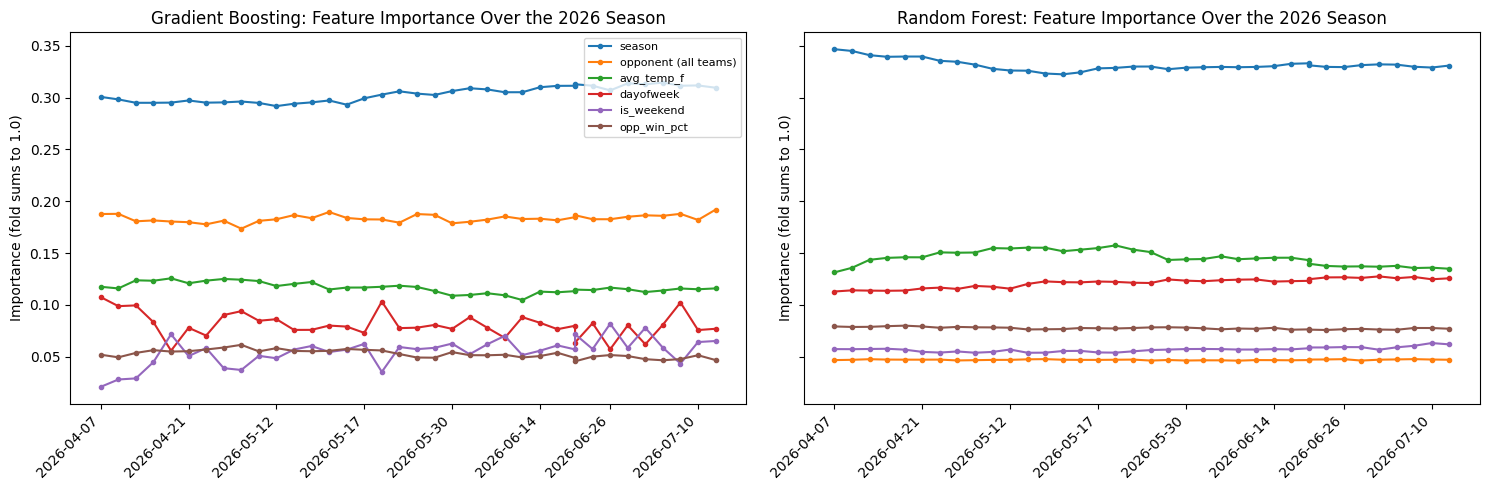

In [6]:
top_features = avg_importance["Gradient Boosting"].sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, label in zip(axes, ["Gradient Boosting", "Random Forest"]):
    traj = importance_over_time[label][top_features]
    for col in top_features:
        ax.plot(traj.index, traj[col], marker=".", label=col)
    ax.set_title(f"{label}: Feature Importance Over the 2026 Season")
    ax.set_xticks(traj.index[::5])
    ax.set_xticklabels(traj.index[::5], rotation=45, ha="right")
    ax.set_ylabel("Importance (fold sums to 1.0)")
axes[0].legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

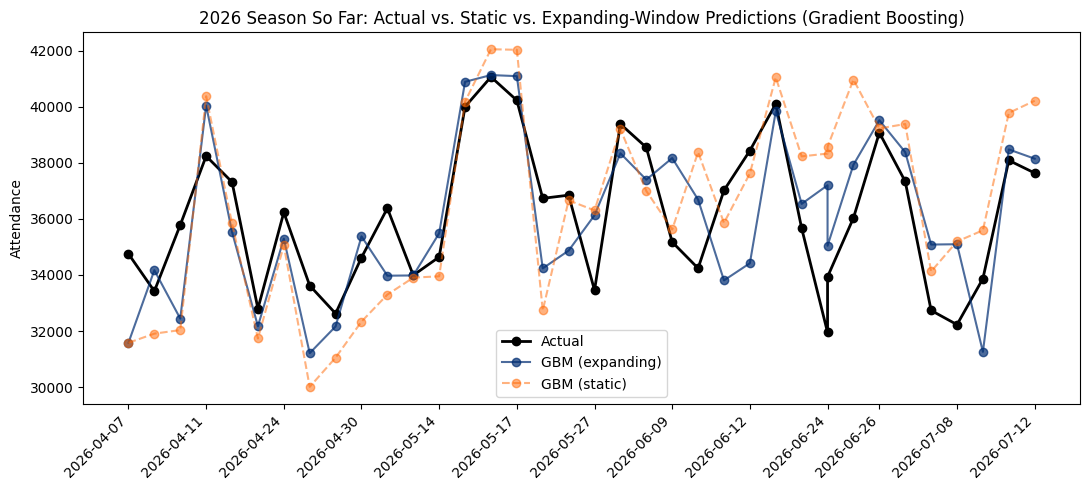

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
dates = test_model[DATE_COL].values
ax.plot(dates, y_test, marker="o", color="black", label="Actual", linewidth=2)
ax.plot(dates, expanding_preds["Gradient Boosting"], marker="o", alpha=0.7, color="#002D72", label="GBM (expanding)")
ax.plot(dates, static_preds["Gradient Boosting"], marker="o", alpha=0.5, color="#FF6600", label="GBM (static)", linestyle="--")
ax.set_xticks(dates[::3])
ax.set_xticklabels(dates[::3], rotation=45, ha="right")
ax.set_ylabel("Attendance")
ax.set_title("2026 Season So Far: Actual vs. Static vs. Expanding-Window Predictions (Gradient Boosting)")
ax.legend()
plt.tight_layout()
plt.show()